In [ ]:
# Install hypertools (run this first on Colab)
import importlib.util
if importlib.util.find_spec('hypertools') is None:
    %pip install -q "hypertools[interactive]"

# Mapping Wikipedia with modern text embeddings

Text embedding models map documents into high-dimensional vector spaces where
nearby vectors correspond to semantically related documents.  In this tutorial
we'll embed HyperTools' sample corpus of Wikipedia articles using a modern
text embedding model
([`BAAI/bge-small-en-v1.5`](https://huggingface.co/BAAI/bge-small-en-v1.5)),
untangle the embedding space with [UMAP](https://umap-learn.readthedocs.io),
discover article groupings with soft (Gaussian mixture) clustering, and
explore the resulting "map" of Wikipedia in 3D.

The embedding model runs through HyperTools' `[text]` extra
(sentence-transformers). You do not have to install it first: HyperTools
installs it on demand the first time an embedding is requested. The install
cell above fetches it ahead of time so the first plot does not pause for the
download.

In [1]:
%matplotlib inline
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['HF_HUB_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# the environment variables above must be set before importing the
# libraries that read them, so these imports are intentionally not at the
# top of the cell.
import numpy as np  # noqa: E402

import hypertools as hyp  # noqa: E402

## Loading the sample Wikipedia corpus

HyperTools ships with a sample corpus of Wikipedia articles, available through
`hyp.load('wiki')`.  The loader returns the raw data directly -- a list
containing one array of documents, where each entry is the (preprocessed)
text of one Wikipedia article.

In [2]:
wiki = hyp.load('wiki')
articles = [str(doc) for doc in wiki[0].ravel()]

print(f'number of articles: {len(articles)}')
print(f'average article length: {np.mean([len(a) for a in articles]):0.0f} characters')
print('\nfirst article (excerpt):\n', articles[0][:250], '...')

number of articles: 3136
average article length: 18048 characters

first article (excerpt):
 a gun salute is the most commonly recognized of the customary gun salutes that are performed by the firing of cannons or artillery as a military honorthe custom stems from naval tradition where a warship would fire its cannons harmlessly out to sea u ...


## Embedding the articles

We'll embed each article with
[`BAAI/bge-small-en-v1.5`](https://huggingface.co/BAAI/bge-small-en-v1.5), a
compact but powerful sentence-embedding model that maps each document onto a
384-dimensional vector.  The model reads at most 512 tokens per document, so
we truncate each article to its first 2,000 characters (typically about 350-450 tokens, comfortably within the limit) --
this also speeds up encoding considerably, and the opening of a Wikipedia
article is nearly always a summary of the whole article anyway.

HyperTools embeds the text itself: every `hyp.plot` call below takes the truncated articles together with `vectorizer='BAAI/bge-small-en-v1.5', semantic=None, corpus=None`, which sends the raw text through that model (`semantic=None` skips the topic-model stage HyperTools applies to text by default).

In [3]:
truncated = [a[:2000] for a in articles]
len(truncated)

3136

## Mapping the corpus with UMAP and soft clustering

Now we can draw the map -- in a single call.  Passing `reduce='UMAP'`
projects the 384-dimensional embeddings down to 3D using UMAP, a nonlinear
method that is particularly good at untangling text embedding spaces.
Passing `cluster={'model': 'GaussianMixture', 'n_clusters': 10}` fits a
10-component Gaussian mixture model to the 3-D UMAP coordinates (the
clustering stage runs after the reduction, on the coordinates that get
drawn, not on the 384-dimensional embeddings) and colors each article
by its *blend* of cluster memberships, automatically: mixture models yield
soft assignments, and HyperTools renders each article's color as an exact
per-point blend of the cluster colors, weighted by that article's mixture
proportions.  Articles deep inside a cluster take on its pure color, while
articles between clusters get smoothly intermediate hues.  The `'.'` format
string together with `markersize=2` plots each article as a small dot.

UMAP is stochastic: re-fitting it gives a different layout on every call unless it is seeded.  We pass `random_state=42` (via the dict form of `reduce=`) so that repeated calls -- the static map here and the animated version below -- produce the same layout.

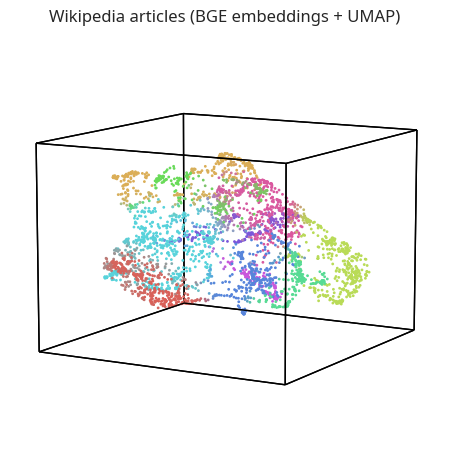

In [4]:
fig = hyp.plot(truncated, '.', markersize=2, vectorizer='BAAI/bge-small-en-v1.5', semantic=None, corpus=None,
               reduce={'model': 'UMAP', 'kwargs': {'random_state': 42}},
               cluster={'model': 'GaussianMixture', 'n_clusters': 10},
               title='Wikipedia articles (BGE embeddings + UMAP)')

Each dot is one Wikipedia article.  Articles about related topics form
clumps and filaments, and the blended colors show where topics shade into one
another.

## Taking a spin around the map

A static projection of a 3D point cloud always hides something.  Setting
`animate='spin'` slowly rotates the camera once around the map (over 10
seconds, at 15 frames per second) so we can inspect it from every angle.
`save_path='wikipedia_embeddings.mp4'` encodes the video directly (`.mp4`
uses FFmpeg; a `.gif` needs no external tool at all).

In [5]:
anim = hyp.plot(truncated, '.', markersize=2, vectorizer='BAAI/bge-small-en-v1.5', semantic=None, corpus=None,
                reduce={'model': 'UMAP', 'kwargs': {'random_state': 42}},
                cluster={'model': 'GaussianMixture', 'n_clusters': 10},
                animate='spin', duration=10, rotations=1, frame_rate=15,
                save_path='wikipedia_embeddings.mp4', show=False)

print(f"video: {os.path.getsize('wikipedia_embeddings.mp4')/1e6:0.1f} MB")

video: 1.9 MB


<video controls loop muted autoplay playsinline src="wikipedia_embeddings.mp4" title="A spin around the Wikipedia embedding map" style="max-width: 100%"></video>

[Download the clip](wikipedia_embeddings.mp4)

## Live keywords: mapping fresh articles by category (GH #187)

The corpus above is a fixed snapshot bundled with HyperTools. We can also
build a corpus on the fly: pick a set of keywords grouped into categories,
fetch the current live article for each keyword straight from Wikipedia via
the [`Wikipedia-API`](https://github.com/martin-majlis/Wikipedia-API)
package, embed them with the same model as above, and plot the resulting
point cloud colored by keyword category -- with a volumetric density
overlay showing where each category's articles cluster in embedding space.


In [8]:
import importlib.util
if importlib.util.find_spec('wikipediaapi') is None:
    %pip install -q wikipedia-api

In [6]:
import wikipediaapi

wiki_api = wikipediaapi.Wikipedia(
    user_agent='hypertools-tutorial (https://github.com/ContextLab/hypertools)',
    language='en')

# a keyword set spanning four unrelated categories
keyword_groups = {
    'neuroscience': ['Neuroscience', 'Neuron', 'Cerebral cortex', 'Synapse',
                      'Hippocampus'],
    'astronomy': ['Astronomy', 'Black hole', 'Galaxy', 'Exoplanet', 'Nebula'],
    'music': ['Jazz', 'Classical music', 'Rock music', 'Hip hop music',
              'Opera'],
    'sports': ['Basketball', 'Soccer', 'Tennis', 'Swimming', 'Cricket'],
}

titles, live_texts, categories = [], [], []
for category, keywords in keyword_groups.items():
    for kw in keywords:
        page = wiki_api.page(kw)
        if not page.exists():
            print(f'  (skipping {kw!r}: no such article)')
            continue
        titles.append(kw)
        # the summary is already a clean, self-contained excerpt of the
        # live article -- fall back to the full text for unusually short
        # summaries
        live_texts.append(page.summary if len(page.summary) > 200
                           else page.text)
        categories.append(category)

print(f'fetched {len(titles)} live articles across '
      f'{len(keyword_groups)} categories:')
for title, category in zip(titles, categories):
    print(f'  [{category}] {title}')


fetched 20 live articles across 4 categories:
  [neuroscience] Neuroscience
  [neuroscience] Neuron
  [neuroscience] Cerebral cortex
  [neuroscience] Synapse
  [neuroscience] Hippocampus
  [astronomy] Astronomy
  [astronomy] Black hole
  [astronomy] Galaxy
  [astronomy] Exoplanet
  [astronomy] Nebula
  [music] Jazz
  [music] Classical music
  [music] Rock music
  [music] Hip hop music
  [music] Opera
  [sports] Basketball
  [sports] Soccer
  [sports] Tennis
  [sports] Swimming
  [sports] Cricket


### Embedding and mapping the live articles

We hand the live articles to `hyp.plot` with the same
`vectorizer='BAAI/bge-small-en-v1.5'` as above, and plot them with `hue=` set to each article's keyword
category -- `hyp.plot` assigns each category a distinct color
automatically.


In [7]:
live_truncated = [t[:2000] for t in live_texts]
len(live_truncated)

20

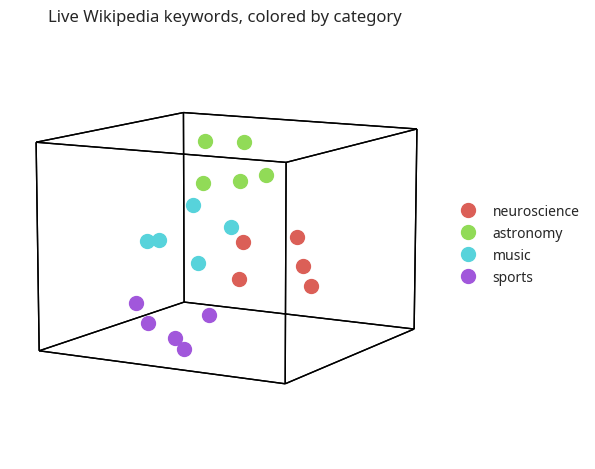

In [8]:
fig = hyp.plot(live_truncated, '.', markersize=20, vectorizer='BAAI/bge-small-en-v1.5', semantic=None, corpus=None,
               reduce={'model': 'UMAP', 'kwargs': {'random_state': 42}},
               hue=categories, legend=True,
               title='Live Wikipedia keywords, colored by category')

### Volumetric density overlay

Passing `density=True` alongside `hue=` adds a translucent volumetric KDE
"glow" around each colored group (GH #108, #191), making it easier to see
where each category's articles concentrate in the embedding space -- even
with a modest number of live-fetched articles.


Because we seeded UMAP above, this plot has the *same* layout as the previous one -- just with the density overlay added.

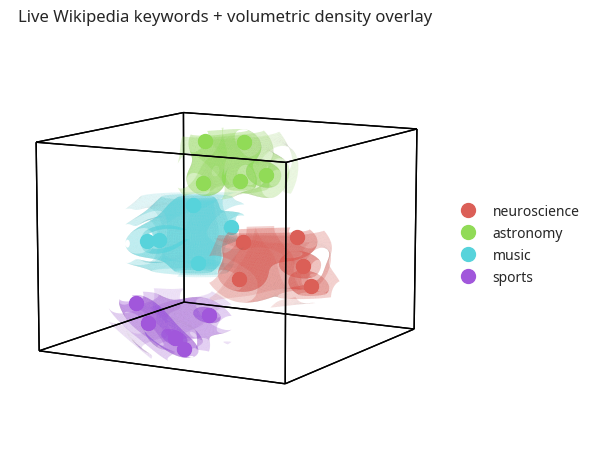

In [9]:
fig = hyp.plot(live_truncated, '.', markersize=20, vectorizer='BAAI/bge-small-en-v1.5', semantic=None, corpus=None,
               reduce={'model': 'UMAP', 'kwargs': {'random_state': 42}},
               hue=categories, legend=True, density=True,
               title='Live Wikipedia keywords + volumetric density overlay')

## Next steps

Try a larger embedding model (e.g. `BAAI/bge-base-en-v1.5`), a different
number of mixture components, or swap UMAP for t-SNE (`reduce='TSNE'`).  You
can also explore the map interactively with `backend='plotly'`, or use
`hyp.plot(..., explore=True)` to hover over individual articles.